In [ ]:
from google.colab import files

uploaded = files.upload()

Saving eCommerce_Customer_support_data.csv to eCommerce_Customer_support_data (1).csv


#  Import libraires


In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#  Load Dataset


In [ ]:
df = pd.read_csv("eCommerce_Customer_support_data.csv")

df.head()


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


#  Dataset Shape


In [ ]:
df.shape

(85907, 20)

# Data Information


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

# Missing values


In [ ]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


# Duplicates Records


In [ ]:
df.duplicated().sum()

np.int64(0)

# Drop Unnecessary Columns

In [ ]:
df = df.drop(columns=['Unique id','Order_id','Customer Remarks'], errors='ignore')

# Convert Date Columns

In [ ]:
if 'Issue_reported at' in df.columns and 'issue_responded' in df.columns:

    df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M')
    df['issue_responded'] = pd.to_datetime(df['issue_responded'], format='%d/%m/%Y %H:%M')

    df['response_time'] = (df['issue_responded'] - df['Issue_reported at']).dt.seconds

# Dataset Description

In [ ]:
df.describe()

,Issue_reported at,issue_responded,Item_price,connected_handling_time,CSAT Score,response_time
count,85907,85907,17206.000000,242.000000,85907.000000,85907.000000
mean,2023-08-16 22:29:05.784394752,2023-08-17 00:45:58.980990976,5660.774846,462.400826,4.242157,7142.084813
min,2023-07-28 20:42:00,2023-08-01 00:00:00,0.000000,0.000000,1.000000,0.000000
25%,2023-08-09 12:48:00,2023-08-09 15:02:30,392.000000,293.000000,4.000000,120.000000
50%,2023-08-16 18:22:00,2023-08-16 20:57:00,979.000000,427.000000,5.000000,360.000000
75%,2023-08-24 17:33:30,2023-08-24 19:27:00,2699.750000,592.250000,5.000000,3300.000000
max,2023-08-31 23:58:00,2023-08-31 23:59:00,164999.000000,1986.000000,5.000000,86340.000000
std,NaN,NaN,12825.728411,246.295037,1.378903,16249.423525


# CHARTS 📊

# Chart 1 - CSAT Score Distribution

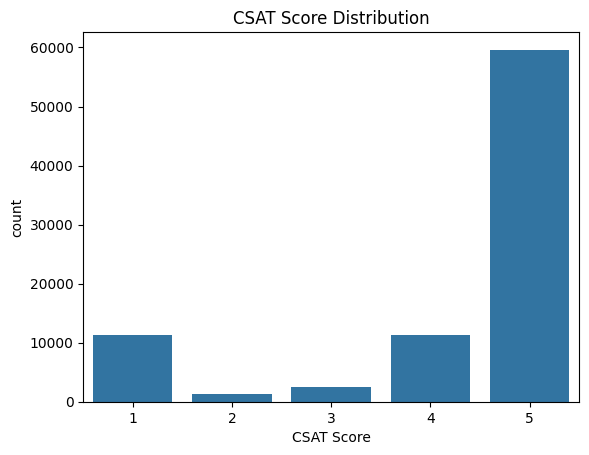

In [ ]:
sns.countplot(x='CSAT Score',data=df)

plt.title("CSAT Score Distribution")

plt.show()

# Chart 2 – Support Channel vs CSAT

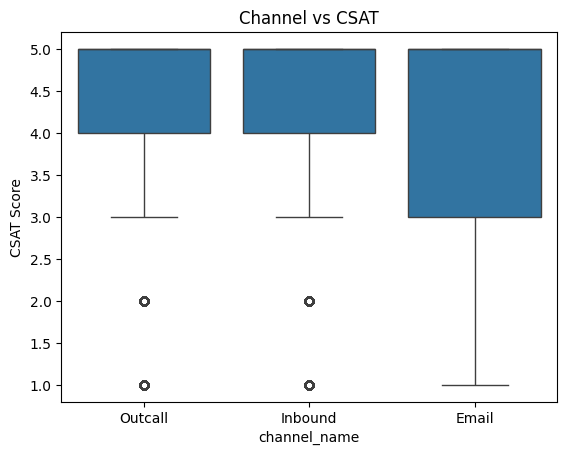

In [ ]:
sns.boxplot(x='channel_name',y='CSAT Score',data=df)

plt.title("Channel vs CSAT")

plt.show()

# Chart 3 – Agent Shift vs CSAT

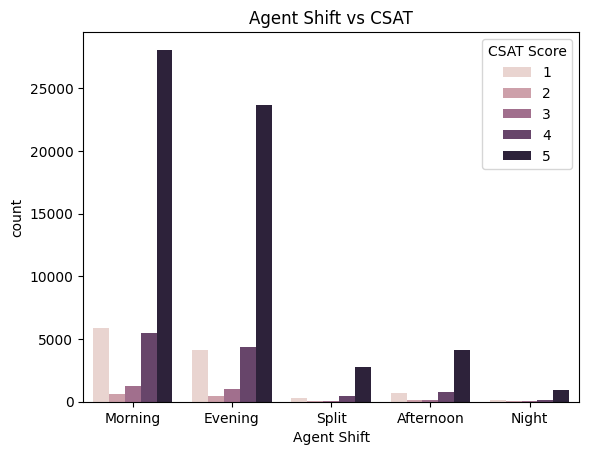

In [ ]:
sns.countplot(x='Agent Shift',hue='CSAT Score',data=df)

plt.title("Agent Shift vs CSAT")

plt.show()

# Chart 4 – Product Category Distribution

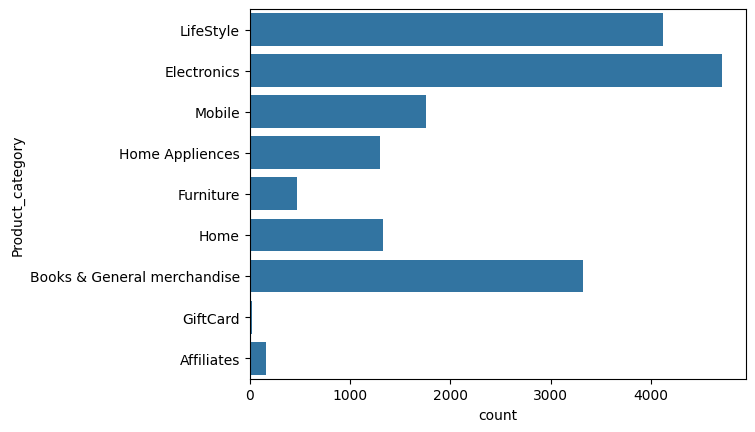

In [ ]:
sns.countplot(y='Product_category',data=df)

plt.show()

# Chart 5 – Item Price Distribution

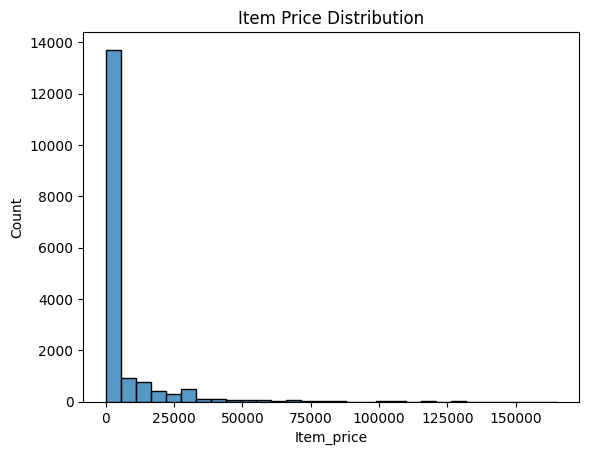

In [ ]:
sns.histplot(df['Item_price'],bins=30)

plt.title("Item Price Distribution")

plt.show()

# Chart 6 – Handling Time Distribution

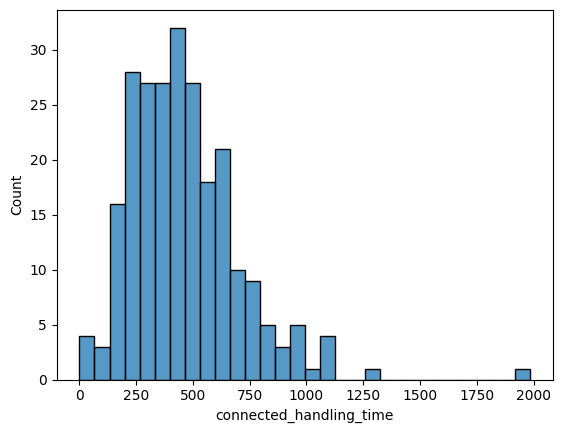

In [ ]:
sns.histplot(df['connected_handling_time'],bins=30)

plt.show()

# Chart 7 – Channel Distribution

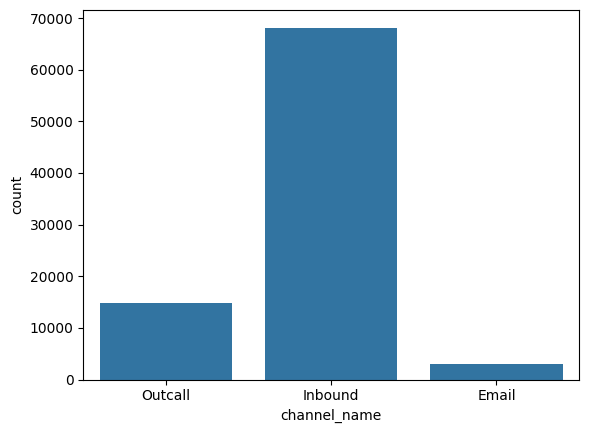

In [ ]:
sns.countplot(x='channel_name',data=df)

plt.show()

# Chart 8 – Category Distribution

In [ ]:
sns.countplot(y='category',data=df)

plt.show()

# Chart 9 – Subcategory Distribution

In [ ]:
sns.countplot(y='Sub-category',data=df)

plt.show()

# Chart 10 – CSAT vs Price

In [ ]:
sns.boxplot(x='CSAT Score',y='Item_price',data=df)

plt.show()

# Chart 11 – CSAT vs Handling Time

In [ ]:
sns.boxplot(x='CSAT Score',y='connected_handling_time',data=df)

plt.show()

# Chart 12 – Agent Shift Distribution

In [ ]:
sns.countplot(x='Agent Shift',data=df)

plt.show()

# Chart 13 – Tenure Bucket

In [ ]:
sns.countplot(x='Tenure Bucket',data=df)

plt.show()

# Chart 14 – Correlation Heatmap

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# Chart 15 – Pair Plot

In [ ]:
sns.pairplot(df.select_dtypes(include=np.number))

plt.show()

# Encode Categorical Columns

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:

    df[col] = le.fit_transform(df[col])

# Define Features and Target

In [ ]:
X = df.drop(['CSAT Score', 'Issue_reported at', 'issue_responded'], axis=1)
y = df['CSAT Score']

# Split Dataset

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

# Model 1 – Logistic Regression

In [ ]:
model1 = LogisticRegression(max_iter=1000)

model1.fit(X_train,y_train)

pred1 = model1.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred1))

print(classification_report(y_test,pred1))

# Model 2 – Decision Tree

In [ ]:
model2 = DecisionTreeClassifier()

model2.fit(X_train,y_train)

pred2 = model2.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred2))

print(classification_report(y_test,pred2))

# Model 3 – Random Forest

In [ ]:
model3 = RandomForestClassifier()

model3.fit(X_train,y_train)

pred3 = model3.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred3))

print(classification_report(y_test,pred3))

Accuracy: 0.6490513327901292
              precision    recall  f1-score   support

           1       0.24      0.09      0.13      2241
           2       0.02      0.00      0.01       227
           3       0.05      0.01      0.02       503
           4       0.15      0.05      0.07      2277
           5       0.70      0.91      0.79     11934

    accuracy                           0.65     17182
   macro avg       0.23      0.21      0.20     17182
weighted avg       0.54      0.65      0.58     17182



# Cross Validation

In [ ]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

try:
    # 1. Load and Preprocess
    df = pd.read_csv('eCommerce_Customer_support_data.csv')
    df = df.drop(columns=['Unique id','Order_id','Customer Remarks'], errors='ignore')

    # Encode categorical columns
    le = LabelEncoder()
    for col in df.select_dtypes(include='object').columns:
        df[col] = le.fit_transform(df[col].astype(str))

    # Define Features and Target
    X = df.drop(['CSAT Score', 'Issue_reported at', 'issue_responded'], axis=1, errors='ignore')
    y = df['CSAT Score']

    # 2. Run Cross-Validation
    model3 = RandomForestClassifier(n_estimators=50) # Small n_estimators for speed
    scores = cross_val_score(model3, X, y, cv=5)

    print("Cross Validation Scores:", scores)
    print("Average Score:", scores.mean())

except FileNotFoundError:
    print("Error: 'eCommerce_Customer_support_data.csv' not found. Please upload it using the upload cell.")
except Exception as e:
    print(f"An error occurred: {e}")

# Hyperparameter Tuning

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

try:
    # 1. Load and Preprocess
    df = pd.read_csv('eCommerce_Customer_support_data.csv')
    df = df.drop(columns=['Unique id','Order_id','Customer Remarks'], errors='ignore')

    le = LabelEncoder()
    for col in df.select_dtypes(include='object').columns:
        df[col] = le.fit_transform(df[col].astype(str))

    X = df.drop(['CSAT Score', 'Issue_reported at', 'issue_responded'], axis=1, errors='ignore')
    y = df['CSAT Score']

    # 2. Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 3. Tune
    params = {'n_estimators': [100], 'max_depth': [10]} # Reduced for speed
    grid = GridSearchCV(RandomForestClassifier(), params, cv=2)
    grid.fit(X_train, y_train)
    print('Best Parameters:', grid.best_params_)

except FileNotFoundError:
    print("Error: 'eCommerce_Customer_support_data.csv' not found. Please upload the file first.")
except Exception as e:
    print(f"An error occurred: {e}")

# Feature Importance

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # Ensure data is loaded and preprocessed
    df = pd.read_csv('eCommerce_Customer_support_data.csv')
    df = df.drop(columns=['Unique id','Order_id','Customer Remarks'], errors='ignore')

    le = LabelEncoder()
    for col in df.select_dtypes(include='object').columns:
        df[col] = le.fit_transform(df[col].astype(str))

    X = df.drop(['CSAT Score', 'Issue_reported at', 'issue_responded'], axis=1, errors='ignore')
    y = df['CSAT Score']

    # Fit the model
    model3 = RandomForestClassifier(n_estimators=50)
    model3.fit(X, y)

    # Plot Feature Importance
    importances = model3.feature_importances_
    features = X.columns

    plt.figure(figsize=(10,6))
    sns.barplot(x=importances, y=features)
    plt.title("Feature Importance")
    plt.show()

except FileNotFoundError:
    print("Error: 'eCommerce_Customer_support_data.csv' not found. Please upload the file first.")
except Exception as e:
    print(f"An error occurred: {e}")

# Confusion Matrix

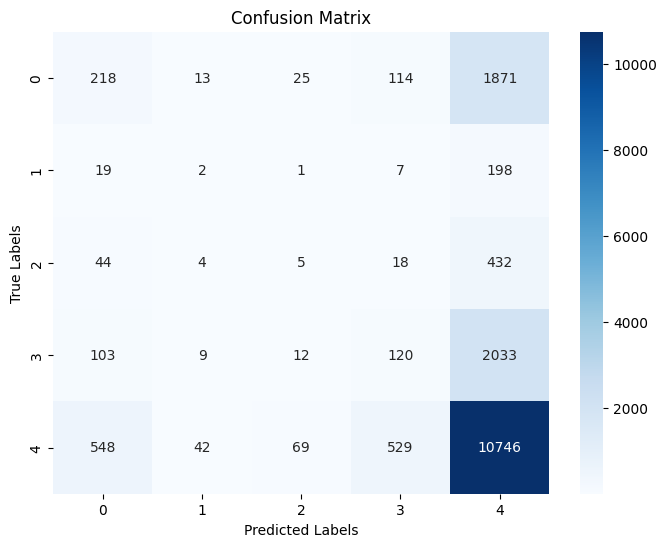

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

try:
    # 1. Load and Preprocess
    df_cm = pd.read_csv('eCommerce_Customer_support_data.csv')
    df_cm = df_cm.drop(columns=['Unique id','Order_id','Customer Remarks'], errors='ignore')
    le = LabelEncoder()
    for col in df_cm.select_dtypes(include='object').columns:
        df_cm[col] = le.fit_transform(df_cm[col].astype(str))

    X_cm = df_cm.drop(['CSAT Score', 'Issue_reported at', 'issue_responded'], axis=1, errors='ignore')
    y_cm = df_cm['CSAT Score']

    # 2. Split and Train
    X_tr, X_te, y_tr, y_te = train_test_split(X_cm, y_cm, test_size=0.2, random_state=42)
    model_cm = RandomForestClassifier(n_estimators=50)
    model_cm.fit(X_tr, y_tr)
    predictions = model_cm.predict(X_te)

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(y_te, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

except FileNotFoundError:
    print("Error: 'eCommerce_Customer_support_data.csv' not found. Please upload the file using cell CDhHaIstQ9FY first.")
except Exception as e:
    print(f"An error occurred: {e}")